**PCA**

**1.EDA**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score

In [3]:
df=pd.read_csv('wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
print(df.shape)

(178, 14)


In [5]:
print('column names:',df.columns)

column names: Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [7]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
X=df.drop('Type',axis=1)
y=df['Type']
print('Features shape:',X.shape)
print('Target shape:',y.shape)

Features shape: (178, 13)
Target shape: (178,)


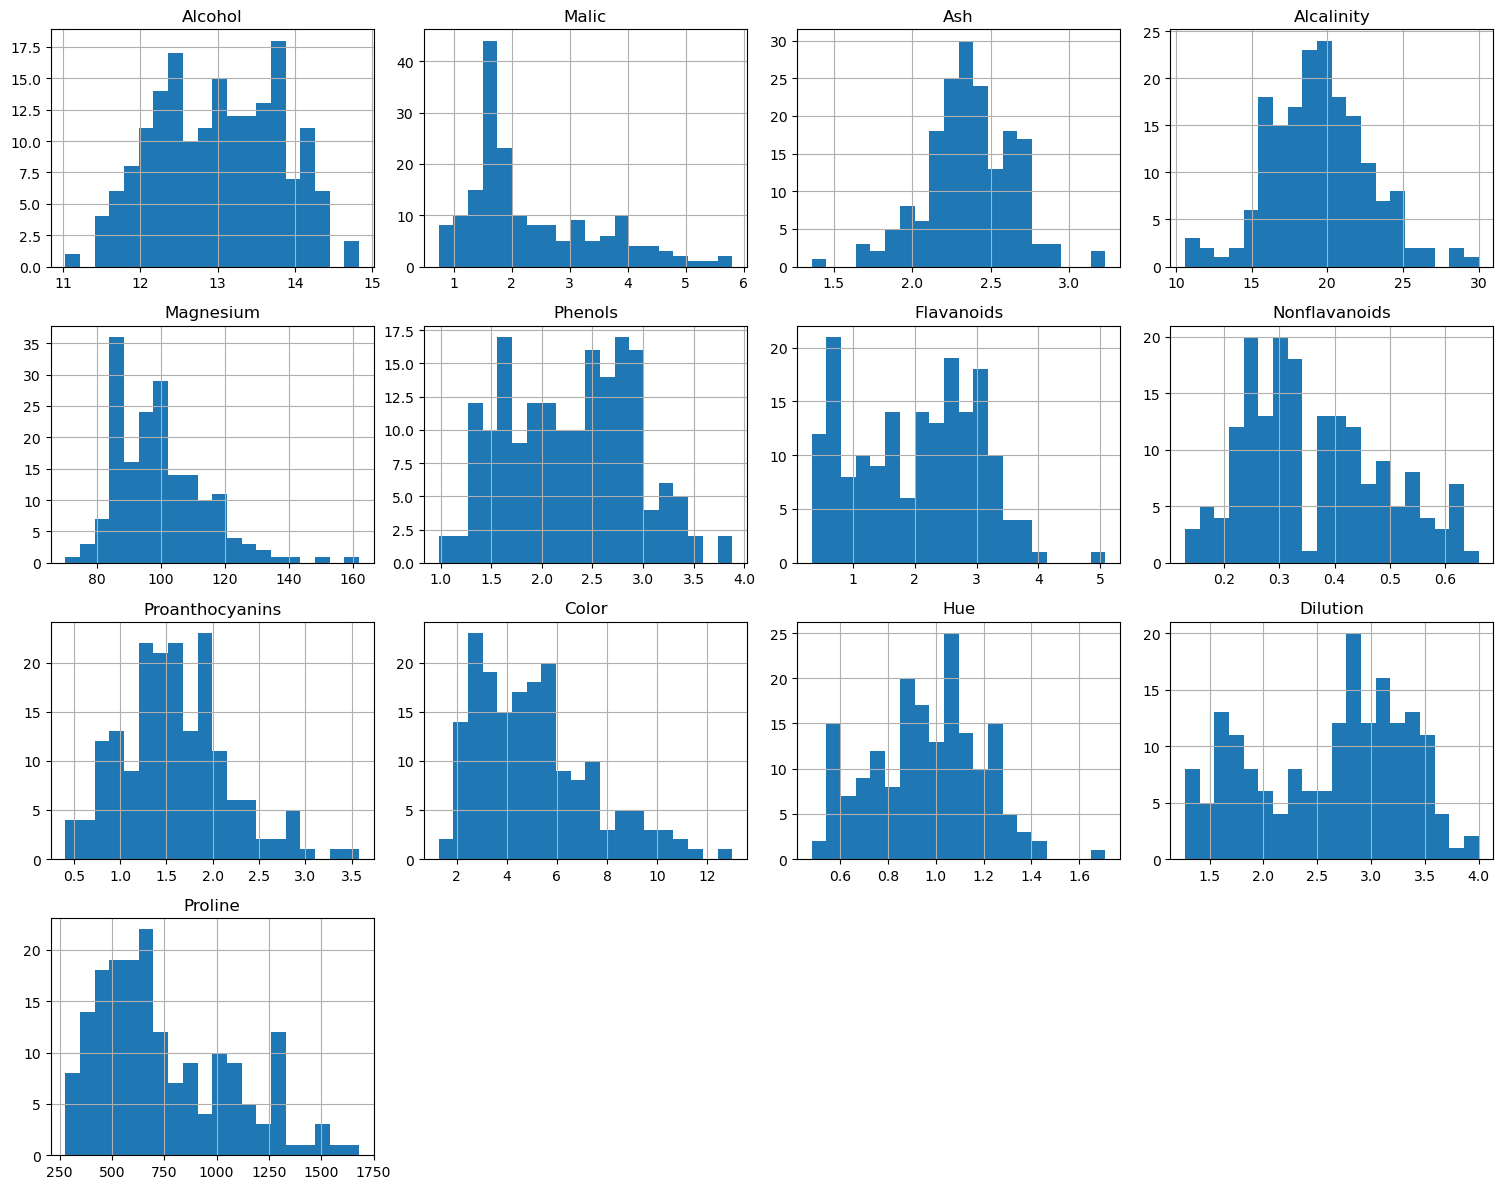

In [12]:
#histogram
X.hist(figsize=(15,12),bins=20)
plt.tight_layout()
plt.show()

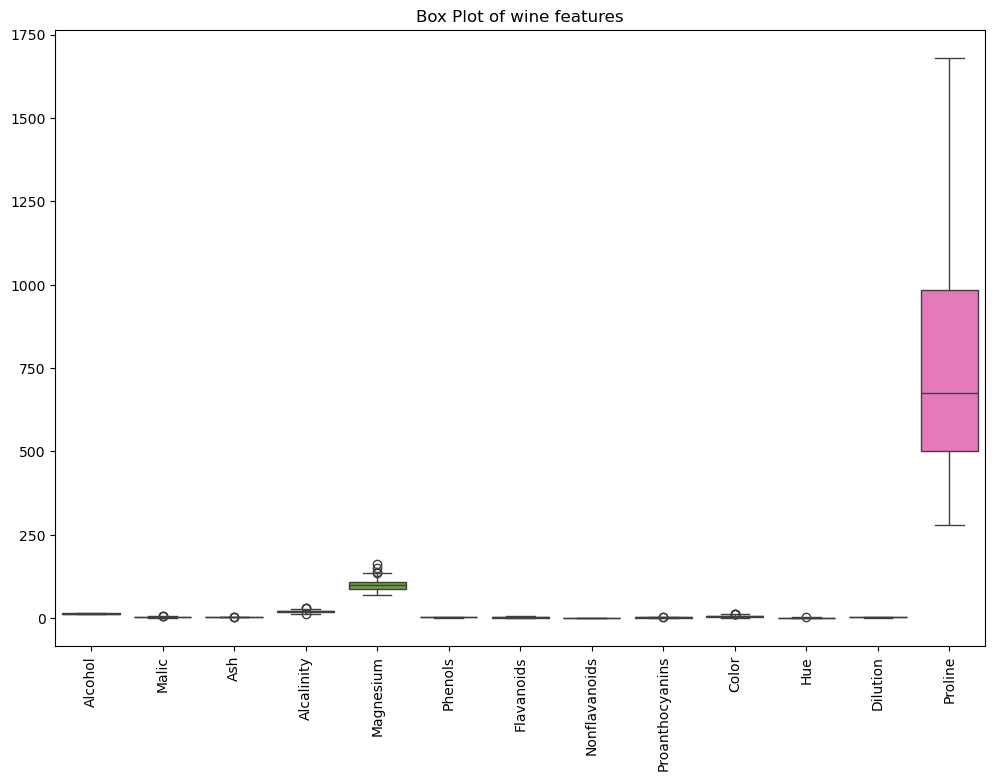

In [14]:
#Box Plot
plt.figure(figsize=(12,8))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title('Box Plot of wine features')
plt.show()

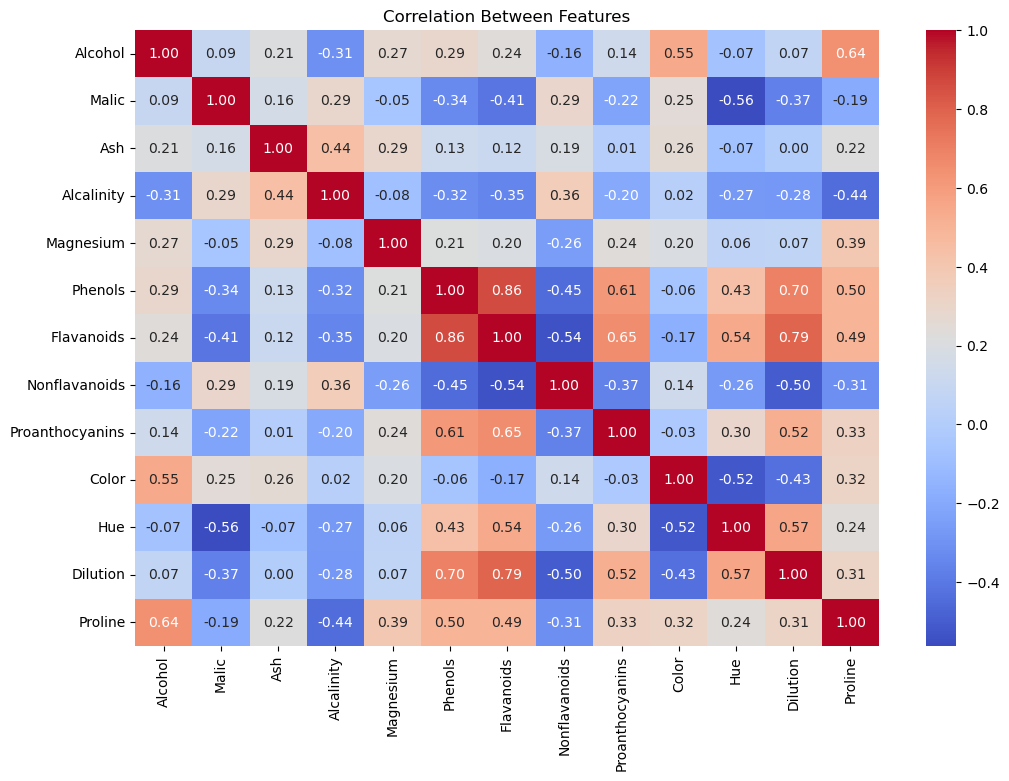

In [15]:
#Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f")

plt.title("Correlation Between Features")
plt.show()

**Dimensionality reduction with PCA**

Standardize the features

In [23]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled[:5])

[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


Apply PCA

In [24]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)
print('PCA Shape:',X_pca.shape)

PCA Shape: (178, 13)


In [27]:
#explained variance
explained_variance=pca.explained_variance_ratio_
print('explained variance ratio:')
print(explained_variance)


explained variance ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


In [28]:
cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


Scree Plot

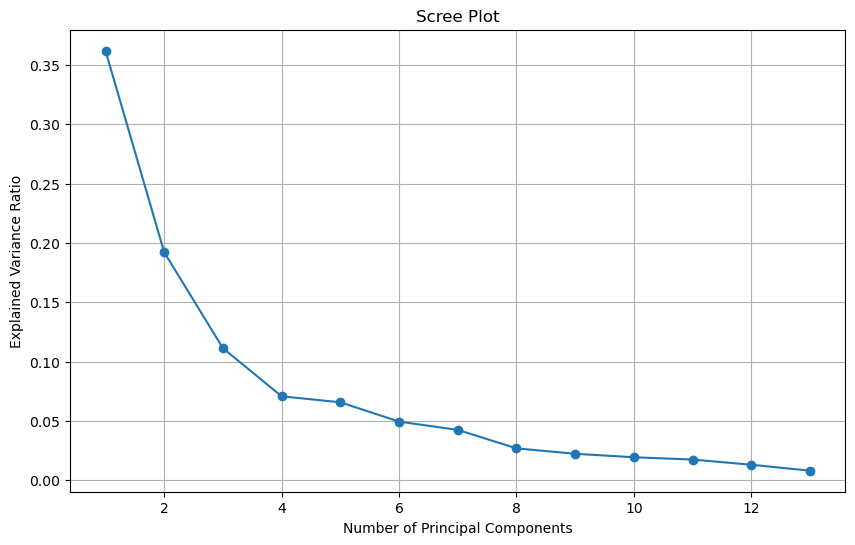

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1),
         explained_variance,
         marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.show()

Cumulative Explained Variance plot


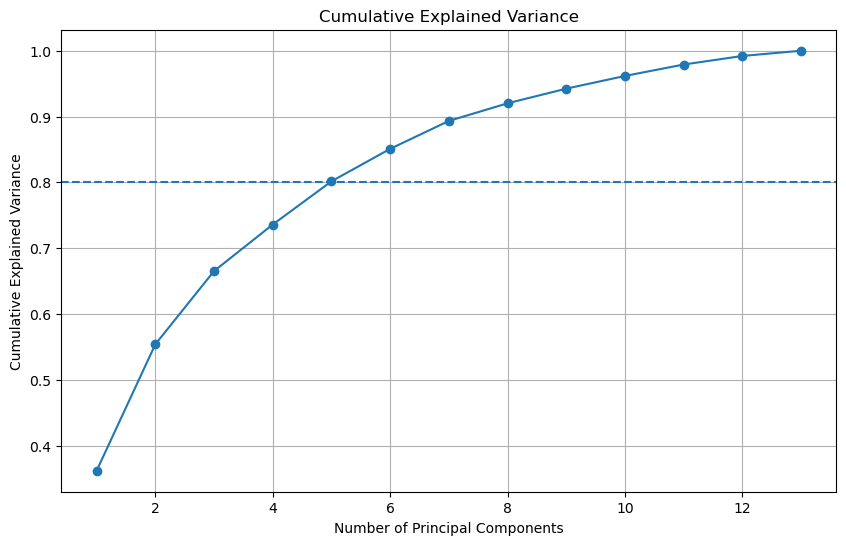

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance,
         marker='o')
plt.axhline(y=0.80, linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid()
plt.show()

For this dataset, 5 principal components explain about 80.16% of the variance, so we can use 5 components.

In [31]:
pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_scaled)
print("Original shape:", X.shape)
print("PCA shape:", X_pca_5.shape)

Original shape: (178, 13)
PCA shape: (178, 5)


In [32]:
#pca dataframe
pca_df = pd.DataFrame(
    X_pca_5,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"]
)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5
0,3.316751,1.443463,-0.165739,-0.215631,0.693043
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655
2,2.516740,1.031151,0.982819,0.724902,-0.251033
3,3.757066,2.756372,-0.176192,0.567983,-0.311842
4,1.008908,0.869831,2.026688,-0.409766,0.298458


PCA Visualization

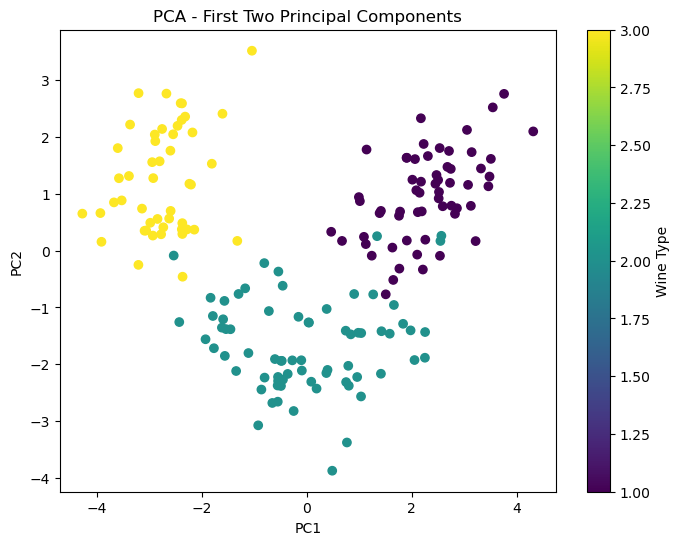

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_5[:, 0],
    X_pca_5[:, 1],
    c=y,
    cmap="viridis"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - First Two Principal Components")
plt.colorbar(label="Wine Type")
plt.show()

**3. Clustering with Original Data**

Apply k-means

In [37]:
import warnings
warnings.filterwarnings('ignore')
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters_original = kmeans_original.fit_predict(X_scaled)
print(clusters_original)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [39]:
#add cluster
df_original = X.copy()
df_original["Cluster"] = clusters_original
df_original.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


Visualize Original Data clusters

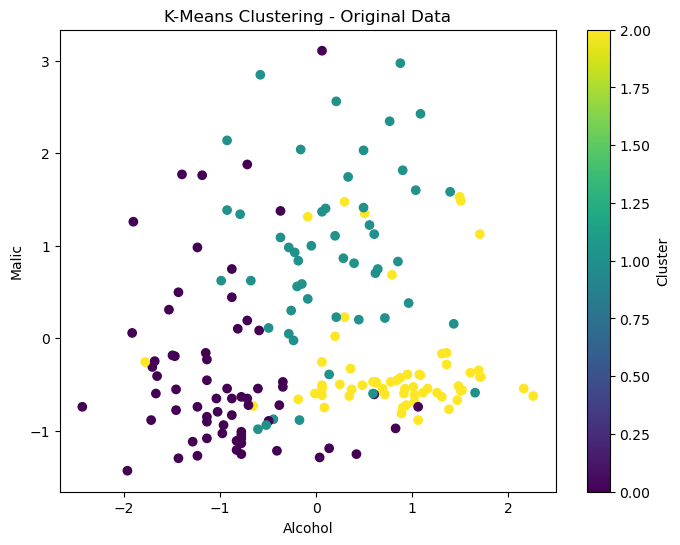

In [41]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters_original,
    cmap="viridis"
)
plt.xlabel("Alcohol")
plt.ylabel("Malic")
plt.title("K-Means Clustering - Original Data")
plt.colorbar(label="Cluster")
plt.show()

In [42]:
silhouette_original = silhouette_score(
    X_scaled,
    clusters_original
)
print("Silhouette Score:", silhouette_original)

Silhouette Score: 0.2848589191898987


In [43]:
db_original = davies_bouldin_score(
    X_scaled,
    clusters_original
)
print("Davies-Bouldin Score:", db_original)

Davies-Bouldin Score: 1.389187977718165


**4.Clustering with PCA data**

apply k-means on pca data

In [44]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters_pca = kmeans_pca.fit_predict(X_pca_5)
print(clusters_pca)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [45]:
#add cluster labels
pca_clustered = pca_df.copy()
pca_clustered["Cluster"] = clusters_pca
pca_clustered.head()

,PC1,PC2,PC3,PC4,PC5,Cluster
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,2
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,2
2,2.516740,1.031151,0.982819,0.724902,-0.251033,2
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,2
4,1.008908,0.869831,2.026688,-0.409766,0.298458,2


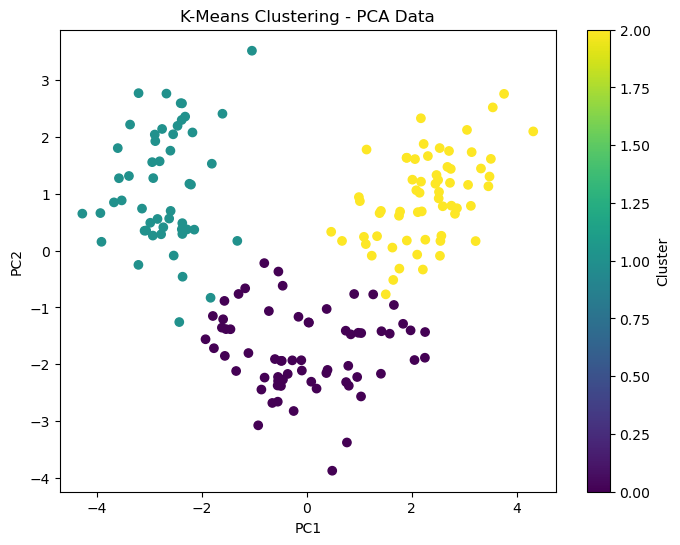

In [46]:
#visualize pca clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_5[:, 0],
    X_pca_5[:, 1],
    c=clusters_pca,
    cmap="viridis"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering - PCA Data")
plt.colorbar(label="Cluster")
plt.show()

In [47]:
#silhouette score
silhouette_pca = silhouette_score(
    X_pca_5,
    clusters_pca
)
print("Silhouette Score:", silhouette_pca)

Silhouette Score: 0.36907631946992286


In [48]:
#davies-bouldin score
db_pca = davies_bouldin_score(
    X_pca_5,
    clusters_pca
)
print("Davies-Bouldin Score:", db_pca)

Davies-Bouldin Score: 1.0932987882612908


**5.Comparision and analysis**

In [49]:
comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [
        silhouette_original,
        silhouette_pca
    ],
    "Davies-Bouldin Score": [
        db_original,
        db_pca
    ]
})

comparison

,Method,Silhouette Score,Davies-Bouldin Score
0,Original Data,0.284859,1.389188
1,PCA Data,0.369076,1.093299


Visualization of comparsion

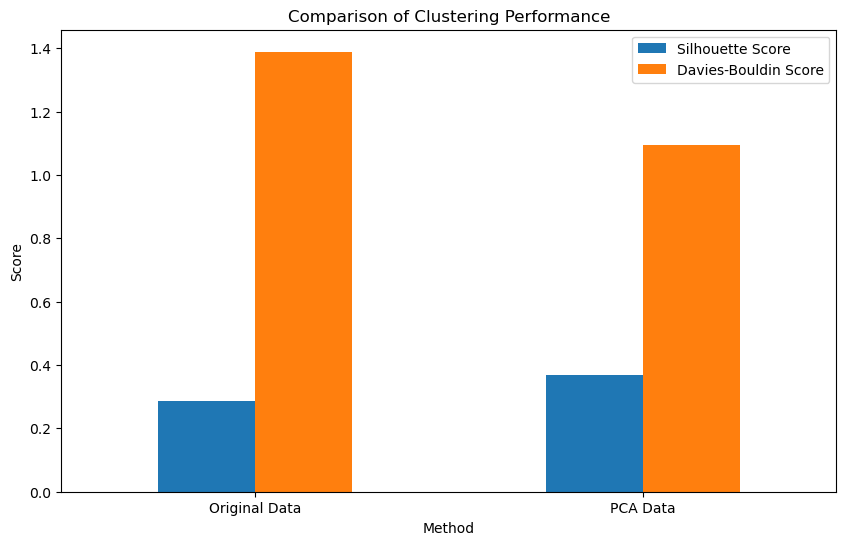

In [50]:
comparison.set_index("Method").plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Comparison of Clustering Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Cluster Distribution

In [51]:
print("Original Data Cluster Distribution:")
print(pd.Series(clusters_original).value_counts().sort_index())

Original Data Cluster Distribution:
0    65
1    51
2    62
Name: count, dtype: int64


In [52]:
print("PCA Data Cluster Distribution:")
print(pd.Series(clusters_pca).value_counts().sort_index())

PCA Data Cluster Distribution:
0    65
1    51
2    62
Name: count, dtype: int64


Conclusion and Insights

1. Key Findings and Insights:

The Wine dataset was analyzed using EDA, PCA, and K-Means clustering. PCA reduced the number of features while retaining most of the important information. Five principal components were selected based on cumulative explained variance. Clustering with PCA data showed better cluster separation than clustering with the original data.

3. Practical Implications:

PCA is useful for reducing the number of features, simplifying data visualization, and reducing computational complexity. Clustering helps identify natural groups or patterns in data without requiring predefined labels. Using PCA before clustering can improve the clustering results when the dataset contains many correlated features.

5. Recommendations:
   
Use PCA when the dataset has many features, especially when features are highly correlated.

Use clustering when you want to discover natural groups in unlabeled data.

Use PCA before clustering when dimensionality reduction improves cluster separation and reduces complexity.

For the Wine dataset, PCA followed by K-Means is recommended because it provided better clustering performance than using the original data directly. The assignment specifically recommends considering the trade-off between dimensionality reduction and direct clustering